In [149]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [150]:
X,y =make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

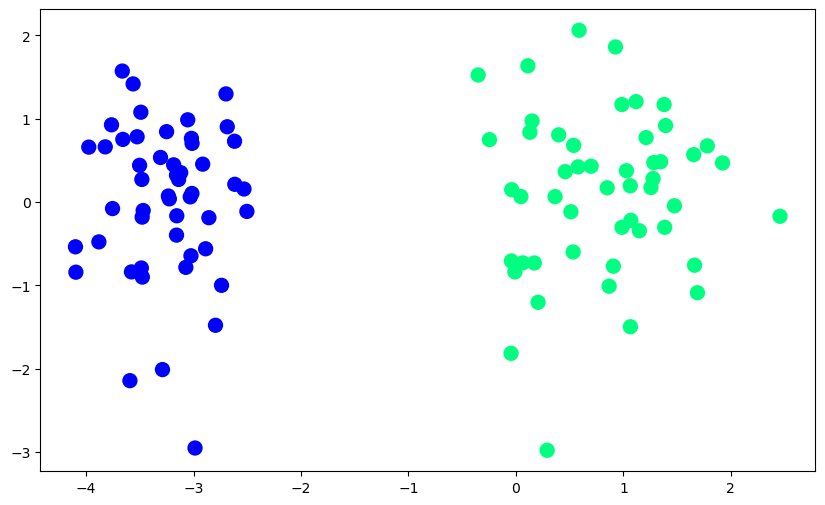

In [151]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100);

# Logistic Regression using Sk learn

In [152]:
from sklearn.linear_model import LogisticRegression

In [153]:
LogReg=LogisticRegression(penalty=None,solver='sag')

In [154]:
LogReg_sk=LogReg.fit(X,y)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [155]:
coef = LogReg_sk.coef_
print(coef)
intercept =LogReg_sk.intercept_
print(intercept)

[[4.79948175 0.21321611]]
[5.76877153]


In [156]:
m=-(coef[0][0]/coef[0][1])
c=-(intercept/coef[0][1])
print(m,c)

-22.509939458088247 [-27.05598326]


In [157]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input + c

(-3.0, 3.0)

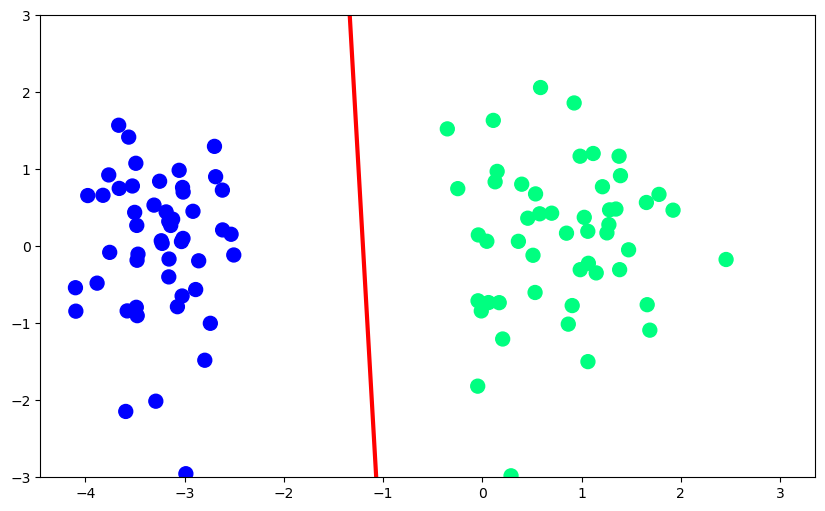

In [158]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,3)

# Logistic Regression using Perceptron (**Step Function**)

In [159]:
def perceptron_step(X,y):
    X=np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr=0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

def step(z):
    return 1 if z>0 else 0

intercept_,coef_ = perceptron_step(X,y)

In [160]:
print(coef_)
print(intercept_)

[1.0198596  0.33857969]
1.3000000000000003


In [161]:
m = -(coef_[0]/coef_[1])
c = -(intercept_/coef_[1])
print(m,c)

-3.012170035579733 -3.8395687654294357


In [162]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + c

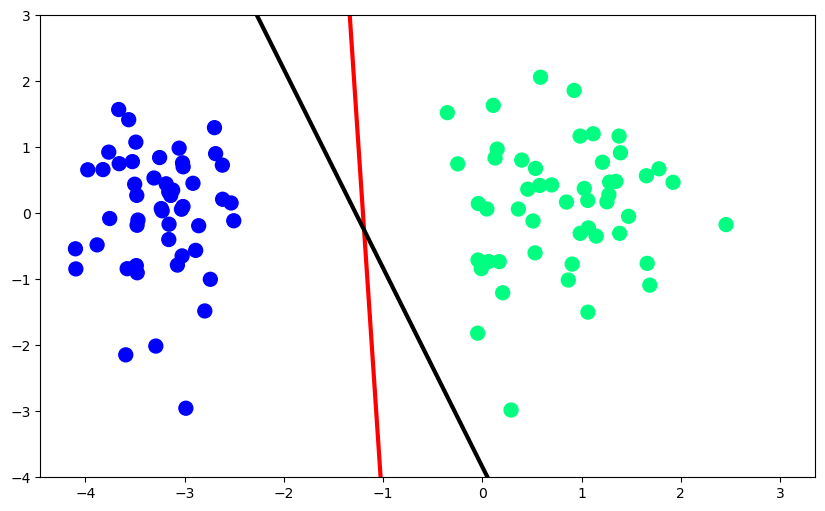

In [163]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-4,3);

# Logistic Regression using Perceptron (**Sigmoid Function**)

In [164]:
def perceptron_sigmoid(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
    return weights[0],weights[1:]

def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [165]:
intercept_,coef_ = perceptron_sigmoid(X,y)

In [166]:
m = -(coef_[0]/coef_[1])
c = -(intercept_/coef_[1])

In [167]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m *x_input2 + c

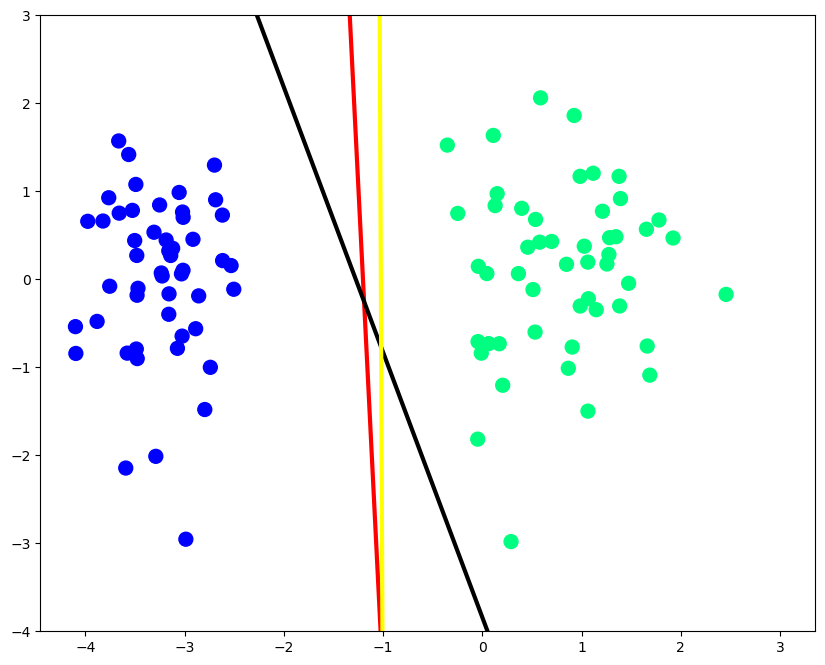

In [168]:
plt.figure(figsize=(10,8))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='yellow',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-4,3);

In [169]:
def gd(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights =weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
    
    return weights[1:],weights[0]

def sigmoid(z):
    return 1/(1+np.exp(-z))

In [170]:
coef_,intercept_=gd(X,y)

In [171]:
m = -(coef_[0]/coef_[1])
c = -(intercept_/coef_[1])

In [172]:
x_input3 =np.linspace(-3,3,100)
y_input3 = m * x_input3 + c

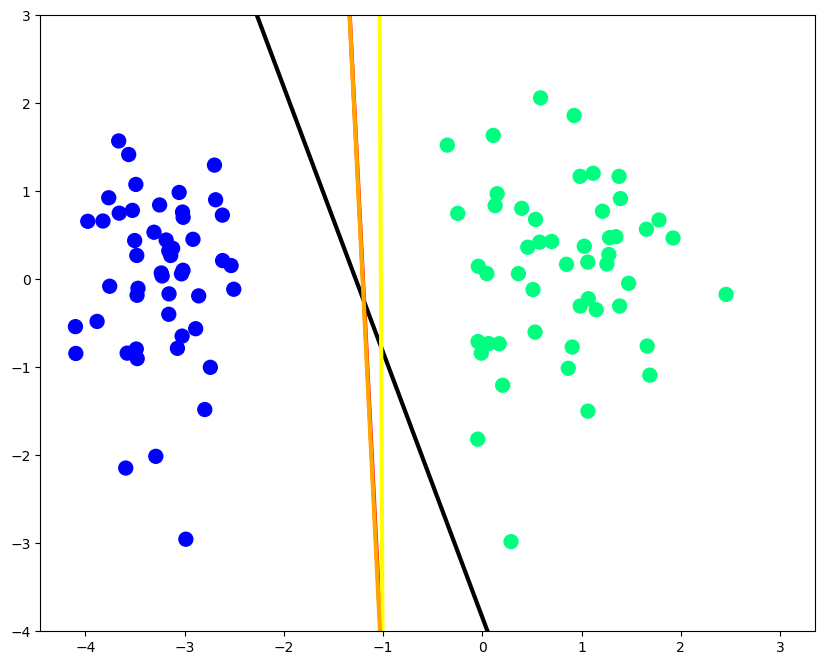

In [175]:
plt.figure(figsize=(10,8))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='yellow',linewidth=3)
plt.plot(x_input3,y_input3,color='orange',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-4,3);